# 0 Imports

In [35]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import umap.umap_ as umap

import pandas as pd
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn import metrics as m
from yellowbrick.cluster import SilhouetteVisualizer

from src.suporte import funcoes_suporte as fs

## 0.1 Funções Suporte

In [22]:
fs.jupyter_settings(altura = 16, largura = 8, fonte = 8)
fs.supressao_notacao(casa_decimal = 2)

# 0.2 Load Data

In [16]:
df = fs.load_pickle('../data/processed/8.data_model_training.pkl')
df.sample(5)

,customer_id,faturamento,recencia_days,frequencia,avg_faturamento,clusters
802,15062,987.86,71,4,987.86,1
3039,13486,1122.41,78,3,1122.41,1
1473,17774,1215.46,96,5,1215.46,1
2961,17370,446.18,72,4,446.18,1
1474,13809,155.05,305,1,155.05,1


In [17]:
df_run = df.drop(columns=['customer_id','clusters'])
df_run.head()

,faturamento,recencia_days,frequencia,avg_faturamento
0,5288.63,302,35,5288.63
1,3079.10,31,18,3079.10
2,7187.34,2,18,7187.34
3,948.25,95,5,948.25
4,635.10,330,6,635.10


## 0.3 Load Model

In [18]:
kmeans = fs.load_pickle('../models/8.model_training.pkl')

# 1. Análise

## 1.1. Visualizações

e:\3_recursos\2_area\profissional\cursos\26_04_1-Fidelidade_Clusterizacao\cluster\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


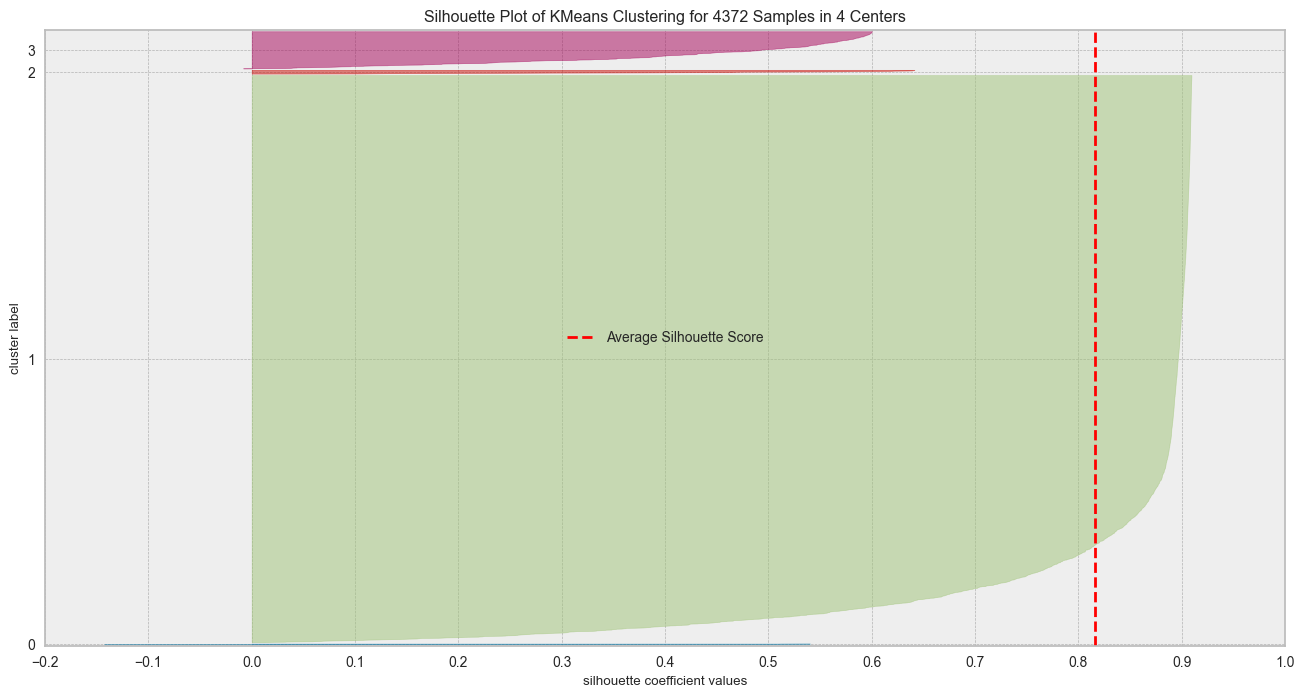

In [26]:
visualiser = SilhouetteVisualizer(kmeans, colors = 'yellowbrick', force_model=True)
visualiser.fit(df_run)
visualiser.finalize()

## 1.1.2 2D plot

In [33]:
df_run2 = df.drop(columns=['customer_id'])
df_run2.head()

,faturamento,recencia_days,frequencia,avg_faturamento,clusters
0,5288.63,302,35,5288.63,3
1,3079.10,31,18,3079.10,1
2,7187.34,2,18,7187.34,3
3,948.25,95,5,948.25,1
4,635.10,330,6,635.10,1


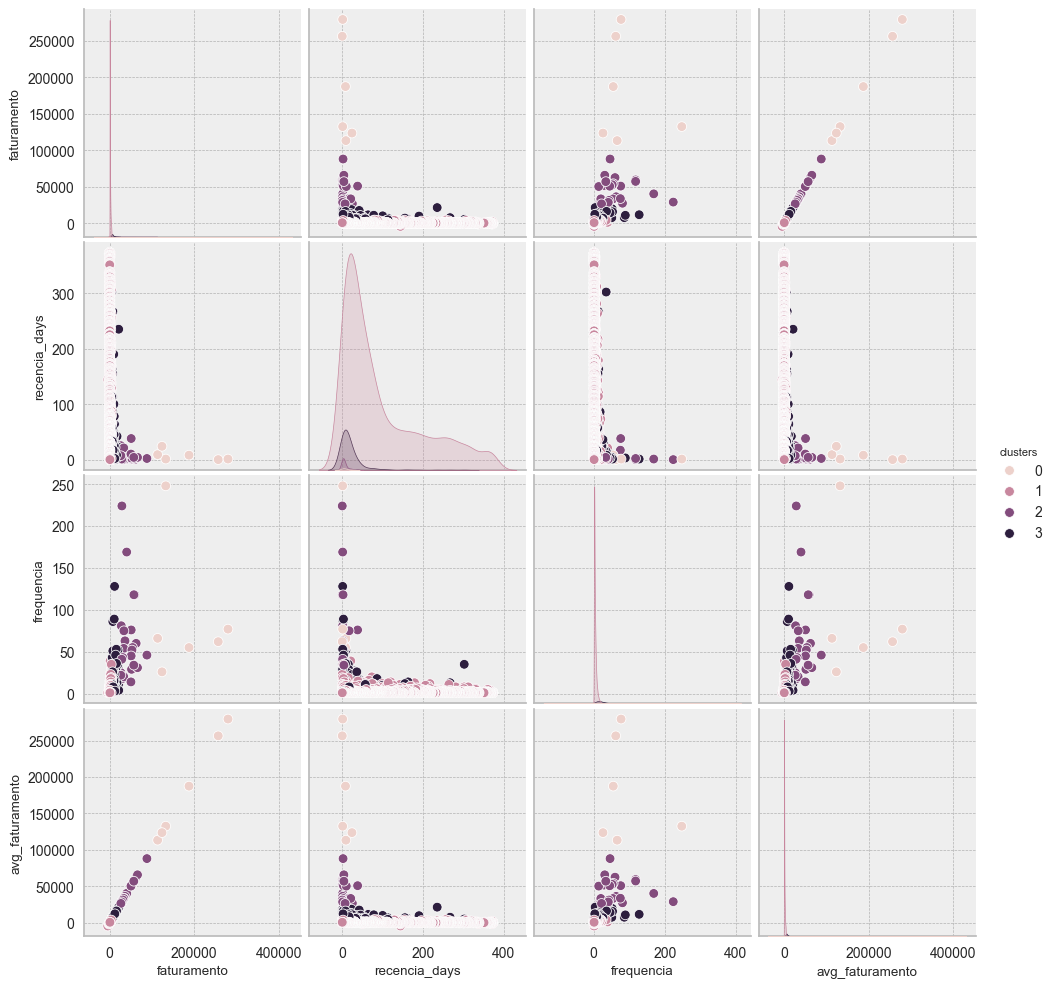

In [34]:
sns.pairplot(df_run2, hue='clusters')

### 3D Plot

In [ ]:
fig = px.scatter_3d(df, x='recencia_days', y='invoice_no', z='faturamento', color='clusters')
fig.show()

## 1.2 UMAP - t-SNE

e:\3_recursos\2_area\profissional\cursos\26_04_1-Fidelidade_Clusterizacao\cluster\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: xlabel='embedding_x', ylabel='embedding_y'>

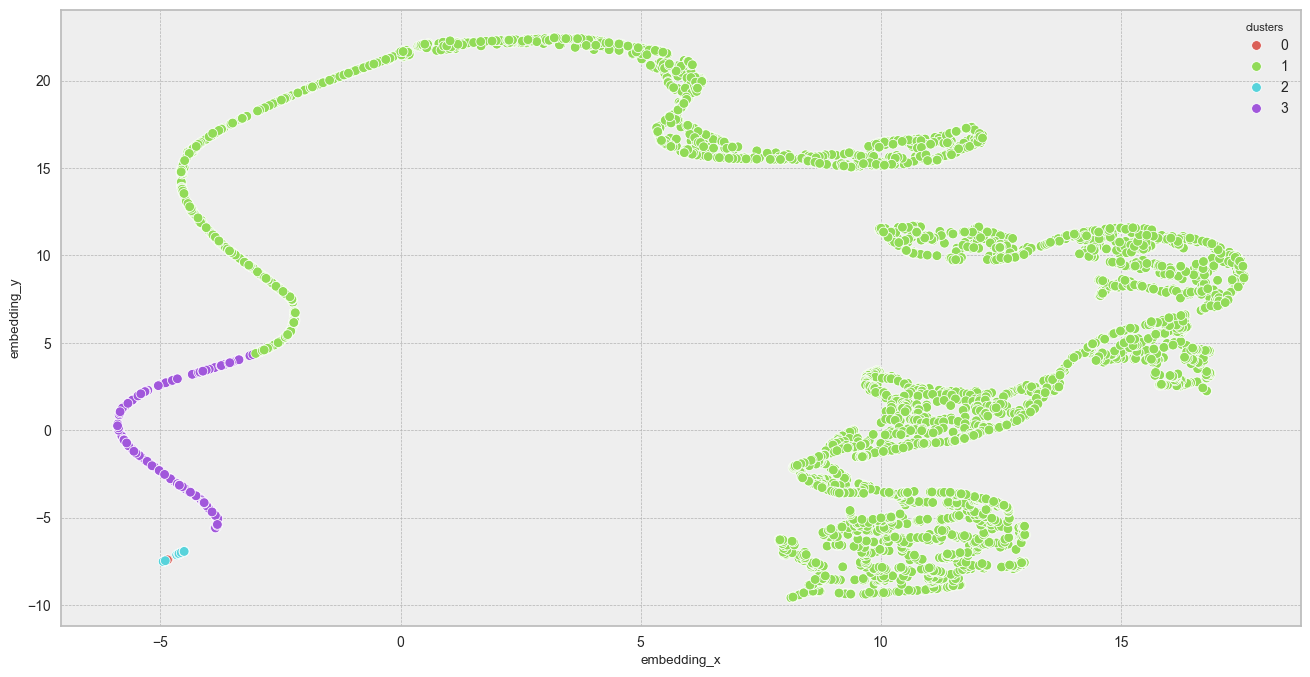

In [ ]:
# Como funciona esse zoom do n_neighbors? Quanto menor n_neighbors mais zoom in? O que difere esse zoom-in e zoom-out em relação a interpretação dos dados?
# UMAP é mais rápido para grandes volumes de dados, mas é mais problemático para a visualização
# t-SNE é melhor para poucos dados, tem uma visualização melhor, mas é muito, mas muito mais pesado de processar.
reducer = umap.UMAP (n_neighbors=20, random_state = 88)
embedding = reducer.fit_transform(df_run2)

df_run2['embedding_x'] = embedding [:,0]
df_run2['embedding_y'] = embedding [:,1]

sns.scatterplot(x='embedding_x',y='embedding_y',
                hue = 'clusters',
                palette=sns.color_palette('hls', n_colors=len(df_run2['clusters'].unique() ) ),
                data = df_run2)

## 1.3. Cluster Profile

In [41]:
# Numero de Pessoas
df_cluster = df[['customer_id', 'clusters']].groupby('clusters').count().reset_index()
df_cluster['perc_customer'] = 100*(df_cluster['customer_id']/df_cluster['customer_id'].sum())

# Média Faturamento
df_media_faturamento = df[['faturamento', 'clusters']].groupby('clusters').mean().reset_index()
df_cluster = pd.merge(df_cluster, df_media_faturamento, how='inner', on="clusters")

# Média Recencia
df_media_faturamento = df[['recencia_days', 'clusters']].groupby('clusters').mean().reset_index()
df_cluster = pd.merge(df_cluster, df_media_faturamento, how='inner', on="clusters")

# Média Frequencia
df_media_faturamento = df[['frequencia', 'clusters']].groupby('clusters').mean().reset_index()
df_cluster = pd.merge(df_cluster, df_media_faturamento, how='inner', on="clusters")

# Média Ticket
df_ticket = df[['avg_faturamento','clusters']].groupby('clusters').mean().reset_index()
df_cluster = pd.merge(df_cluster, df_ticket, how='inner', on="clusters")

df_cluster

,clusters,customer_id,perc_customer,faturamento,recencia_days,frequencia,avg_faturamento
0,0,6,0.14,182181.98,7.17,89.00,182181.98
1,1,4071,93.12,946.70,96.97,3.64,946.70
2,2,28,0.64,42614.39,6.18,57.82,42614.39
3,3,267,6.11,8089.03,20.28,19.53,8089.03


Cluster 01: ( Candidato à Insider )
 - Número de customers: 6 (0,14% do customers)
 - Recência em média: 7 dias
 - Compras em média: 89 compras
 - Receita em média: $182.182,00 dólares

Cluster 02:
 - Número de customers: 31 (0,71% do customers)
 - Recência em média: 14 dias
 - Compras em média: 53 compras
 - Receita em média: $40.543,52 dólares

Cluster 03:
 - Número de customers: 4.335 (99% do customers)
 - Recência em média: 92 dias
 - Compras em média: 5 compras
 - Receita em média: $1.372,57 dólares